In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
print('Libraries imported successfully.')

Libraries imported successfully.


In [3]:
raw_data_path = '../data/raw/data_raw.csv'
df = pd.read_csv(raw_data_path)
print(f'Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset shape: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [14]:
df.isna().any()

customerID          False
gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool

In [15]:
total_charges_num = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_mask = total_charges_num.isna()
missing_rows = df[missing_mask]

print(f'Count of unparseable/blank TotalCharges: {missing_rows.shape[0]}')
missing_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'Churn']]

Count of unparseable/blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


In [ ]:

tc_num = pd.to_numeric(df['TotalCharges'], errors='coerce')

num_series = {
    'tenure': df['tenure'],
    'MonthlyCharges': df['MonthlyCharges'],
    'TotalCharges': tc_num.dropna()
}

stats_list = []
for name, s in num_series.items():
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = s[(s < lower) | (s > upper)]
    stats_list.append({
        'Feature': name,
        'Min': round(s.min(), 2),
        'Q1': round(q1, 2),
        'Median': round(s.median(), 2),
        'Q3': round(q3, 2),
        'Max': round(s.max(), 2),
        'IQR': round(iqr, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers) / len(s) * 100, 2)
    })

outlier_df = pd.DataFrame(stats_list)
outlier_df

,Feature,Min,Q1,Median,Q3,Max,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,tenure,0.00,9.00,29.00,55.00,72.00,46.00,-60.00,124.00,0,0.0
1,MonthlyCharges,18.25,35.50,70.35,89.85,118.75,54.35,-46.02,171.38,0,0.0
2,TotalCharges,18.80,401.45,1397.48,3794.74,8684.80,3393.29,-4688.48,8884.67,0,0.0


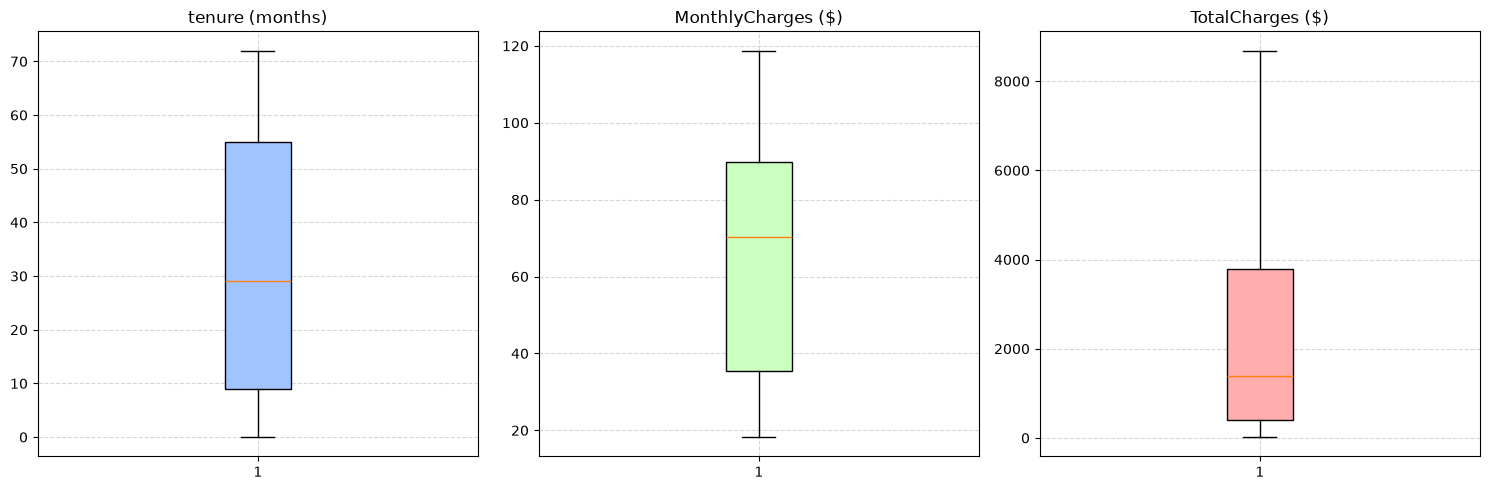

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].boxplot(df['tenure'], patch_artist=True, boxprops=dict(facecolor='#a0c4ff'))
axes[0].set_title('tenure (months)')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].boxplot(df['MonthlyCharges'], patch_artist=True, boxprops=dict(facecolor='#caffbf'))
axes[1].set_title('MonthlyCharges ($)')
axes[1].grid(True, linestyle='--', alpha=0.5)

axes[2].boxplot(tc_num.dropna(), patch_artist=True, boxprops=dict(facecolor='#ffadad'))
axes[2].set_title('TotalCharges ($)')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

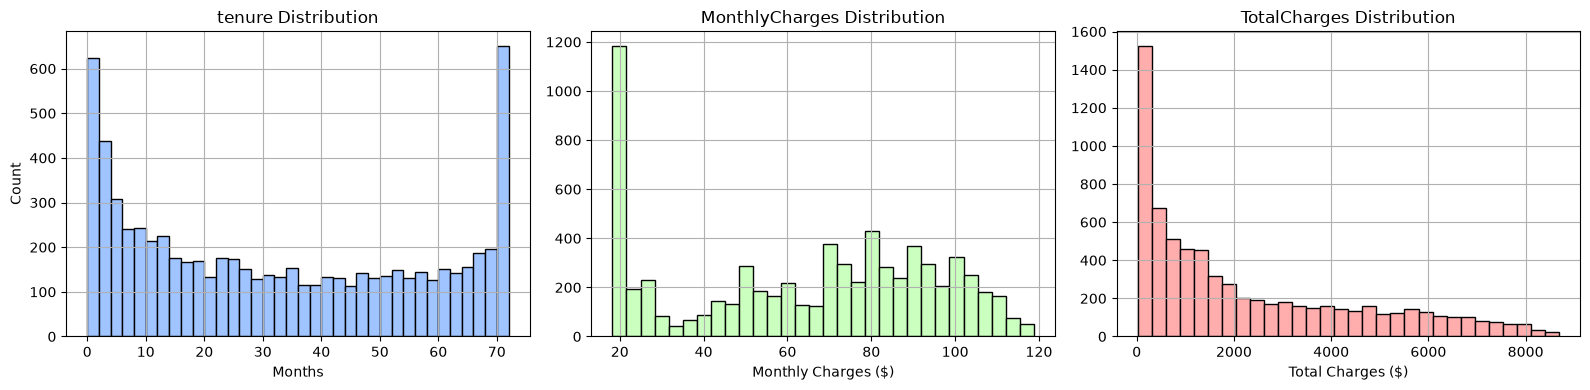

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['tenure'].hist(bins=36, ax=axes[0], color='#a0c4ff', edgecolor='black')
axes[0].set_title('tenure Distribution')
axes[0].set_xlabel('Months')
axes[0].set_ylabel('Count')

df['MonthlyCharges'].hist(bins=30, ax=axes[1], color='#caffbf', edgecolor='black')
axes[1].set_title('MonthlyCharges Distribution')
axes[1].set_xlabel('Monthly Charges ($)')

tc_num.dropna().hist(bins=30, ax=axes[2], color='#ffadad', edgecolor='black')
axes[2].set_title('TotalCharges Distribution')
axes[2].set_xlabel('Total Charges ($)')

plt.tight_layout()
plt.show()

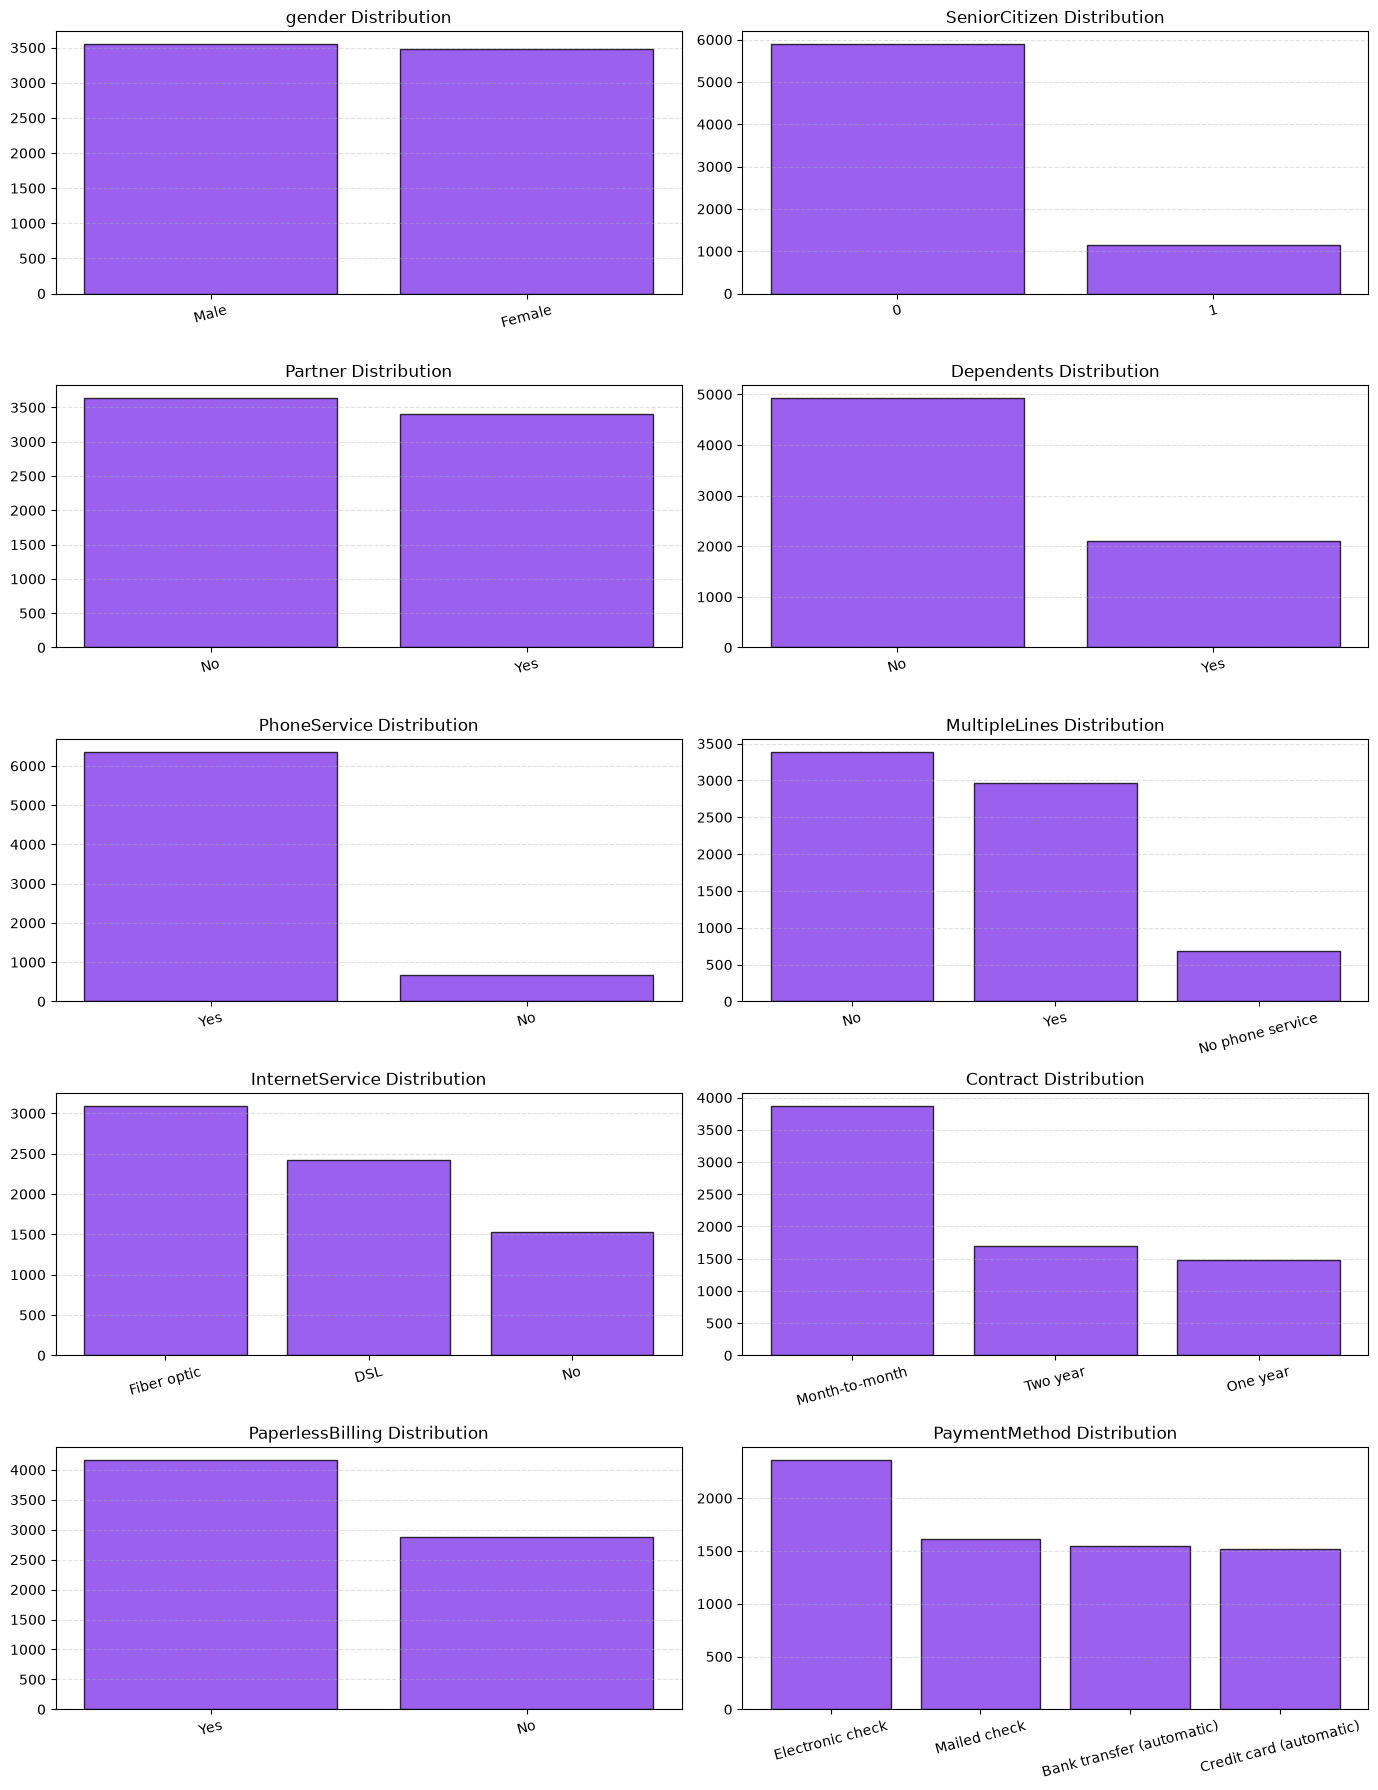

In [11]:
cat_columns = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(cat_columns):
    counts = df[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color='#8338ec', alpha=0.8, edgecolor='black')
    axes[i].set_title(f'{col} Distribution')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

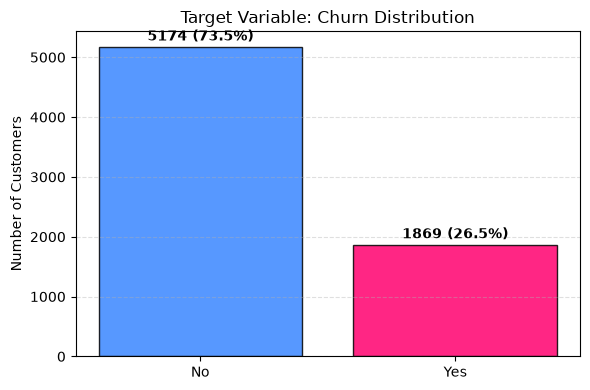

Class Proportions (%):
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [12]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(churn_counts.index, churn_counts.values, color=['#3a86ff', '#ff006e'], edgecolor='black', alpha=0.85)
ax.set_title('Target Variable: Churn Distribution')
ax.set_ylabel('Number of Customers')
ax.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    h = bar.get_height()
    pct = (h / len(df)) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, h + 50, f'{h} ({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print('Class Proportions (%):')
print(churn_pct)